# Purpose

I need a function that pads dates onto my observations. Specifically filling it with NaN values so that I can look at multiple time domains in one run. Right now when I stack the numpy arrays this causes errors.

^^Just realized I am starting with numpy arrays I think so I could do this easier than I maybe thought.

Currently I do this:

In [ ]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import cftime
import nc_time_axis
import sys
import calendar
import re
sys.path.append('C:/Users/madel/Code/GeoNorth/Observational_data')

from obs_utils import *

In [31]:
# test files will be TVC soil temps
# depths are inputted manually at this point
# using a no duplicates approach at this point, which I guess isn't strictly necessary, but useful

site = "TVC"         # BC, TVC, HC, IQ, SC
vari = "TSOI"  #SNOW_DEPTH, H2OSOI, TSOI
# depths = [0.035, 0.10, 0.20, 0.30]
directory_path = f"C:/Users/madel/Code/GeoNorth/Observational_data/{site}_obs/raw/{vari}_ALL"
times, values, depths = pull_files_dupe(directory_path)



In [32]:
check_shapes(times)

Index 0: (186326,)
Index 1: (163014,)
Index 2: (23312,)
Index 3: (163014,)
Index 4: (163014,)
Index 5: (23312,)
Index 6: (186326,)
Index 7: (23312,)
Index 8: (163014,)
Index 9: (186326,)
Index 10: (23312,)
Index 11: (163014,)
Index 12: (23312,)
Index 13: (163014,)
Index 14: (163014,)
Index 15: (23312,)


Heres the issue: column_stack requires the same dimensions.

In [37]:
new_start = cftime.DatetimeNoLeap(1995, 1, 1, has_year_zero=True)
new_end   = cftime.DatetimeNoLeap(2014, 12, 31, has_year_zero=True)

all_times = []
all_values = []

for x in range(0,len(times)):
    new_time, new_values = extend_time_and_values(
        times[x], values[x], new_start, new_end, freq="30T"
    )
    all_times.append(new_time)
    all_values.append(new_values)


In [38]:
check_shapes(all_times)

All arrays match: (350353,)


In [39]:
check_shapes(all_values)

All arrays match: (350353,)


In [40]:
print(depths)

[10.0, 104.0, 10.1, 10.2, 116.0, 117.0, 20.0, 20.1, 20.2, 30.0, 30.1, 30.2, 5.0, 50.0, 50.1, 90.0]


In [42]:
data_2d = np.column_stack(all_values)

print(data_2d.shape)

(350353, 16)


In [44]:
ds_obs = make_obs_ds(vari, data_2d, all_times[0], site, "°C", depths)
ds_obs

<xarray.Dataset> Size: 48MB
Dimensions:  (time: 350353, depth: 16)
Coordinates:
  * time     (time) object 3MB 1995-01-01 00:00:00 ... 2014-12-31 00:00:00
  * depth    (depth) float64 128B 10.0 104.0 10.1 10.2 ... 5.0 50.0 50.1 90.0
Data variables:
    TSOI     (time, depth) float64 45MB nan nan nan nan nan ... nan nan nan nan
Attributes:
    site:     TVC
    source:   GWF observed

In [47]:
def plot_soil_temp_depths(ds):
    fig, ax = plt.subplots(figsize=(14, 5))
    for depth in ds["depth"].values:
        ax.plot(ds["time"].values, ds[f"{vari}"].sel(depth=depth).values, label=f"{depth} m")
    ax.legend(loc="upper right")
    plt.show()

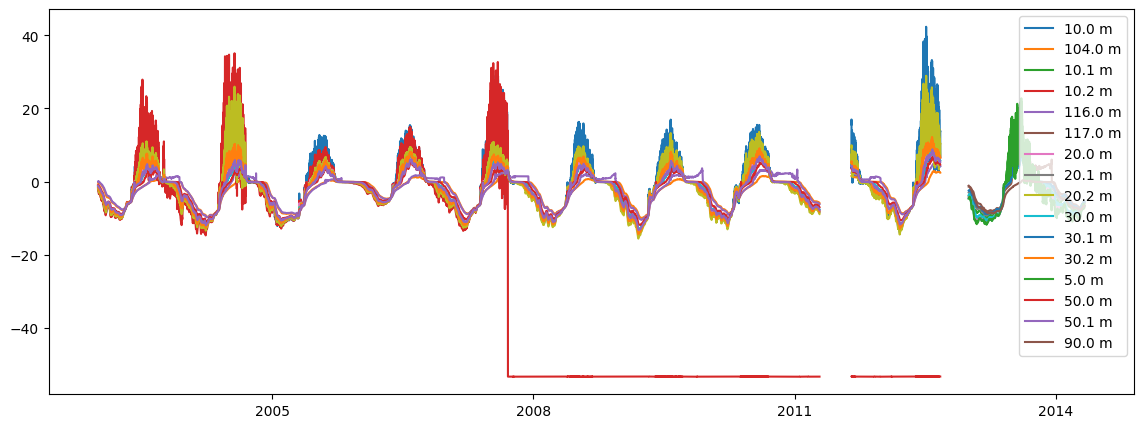

In [48]:
plot_soil_temp_depths(ds_obs)